# Superstore Sales Data Analysis

## Objective

The objective of this project is to analyze the Superstore Sales dataset to understand business performance and identify valuable insights. The analysis focuses on monthly revenue trends, product performance, profitability, customer behavior, and regional sales. These insights can help businesses make informed decisions regarding sales strategy, inventory management, and profit optimization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

## Load Dataset

The dataset is loaded into a Pandas DataFrame for further cleaning, analysis, and visualization.

In [4]:
df = pd.read_csv("SampleSuperstore.csv", encoding="latin1")

## Dataset Overview

Understanding the dataset helps identify the available features and overall data quality before performing analysis.

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,Florida,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,California,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [7]:
df.shape

(9994, 21)

In [8]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [10]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## Data Cleaning

This step checks for missing values, duplicate records, and converts the Order Date column into datetime format for time-based analysis.

In [11]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

## Monthly Revenue Trends

Monthly sales are analyzed to identify seasonal patterns and revenue growth over time.

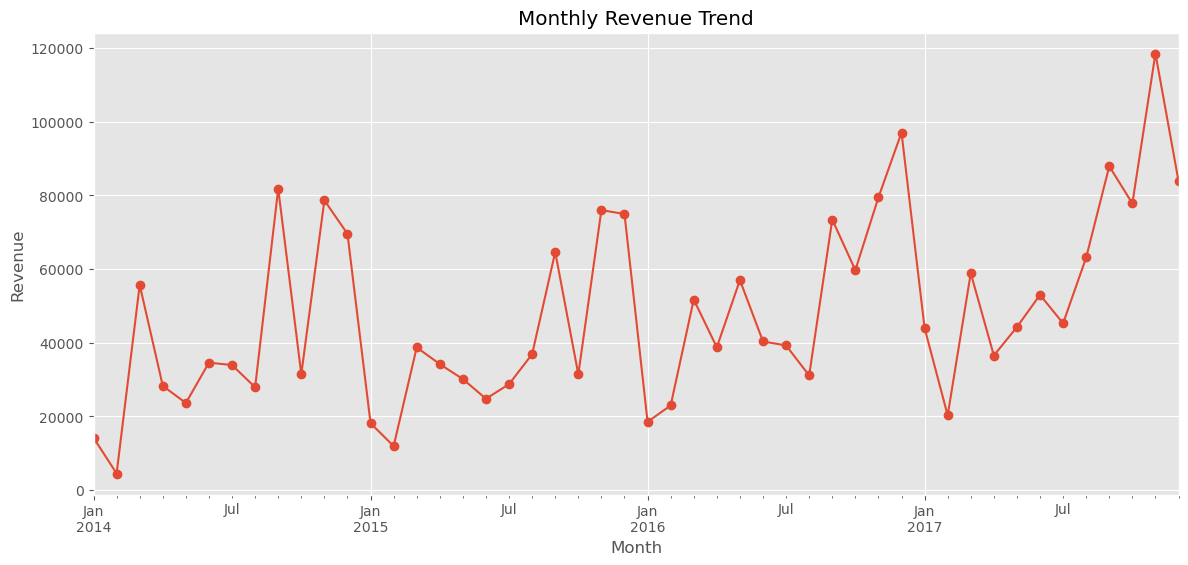

In [15]:
monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()

plt.figure(figsize=(14,6))

monthly_sales.plot(marker="o")

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.grid(True)

plt.savefig("images/monthly_revenue.png")

plt.show()

Monthly revenue shows fluctuations throughout the year. Some months generated significantly higher sales, indicating seasonal demand and promotional opportunities.

## Sales by Category

This analysis compares total sales generated by each product category.

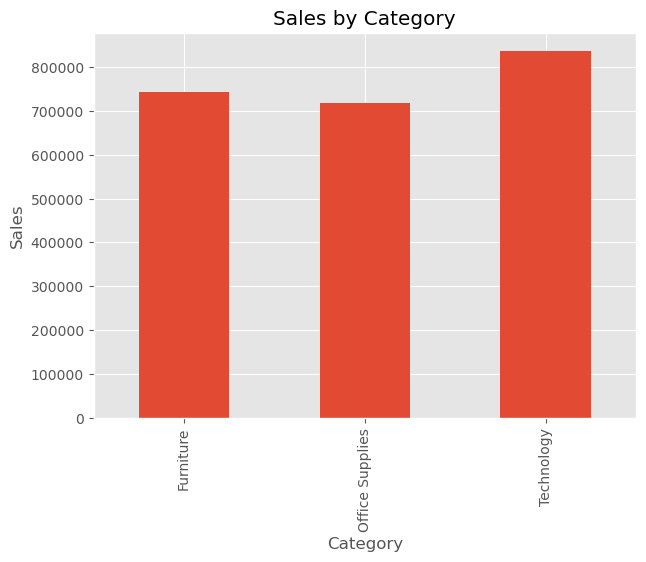

In [16]:
plt.figure(figsize=(7,5))

category_sales = df.groupby("Category")["Sales"].sum()

category_sales.plot(kind="bar")

plt.title("Sales by Category")

plt.ylabel("Sales")

plt.savefig("images/category_sales.png")

plt.show()

Technology products contribute the highest sales, followed by Furniture and Office Supplies.

## Sales by Sub-Category

Sub-category analysis helps identify the most profitable and popular product groups.

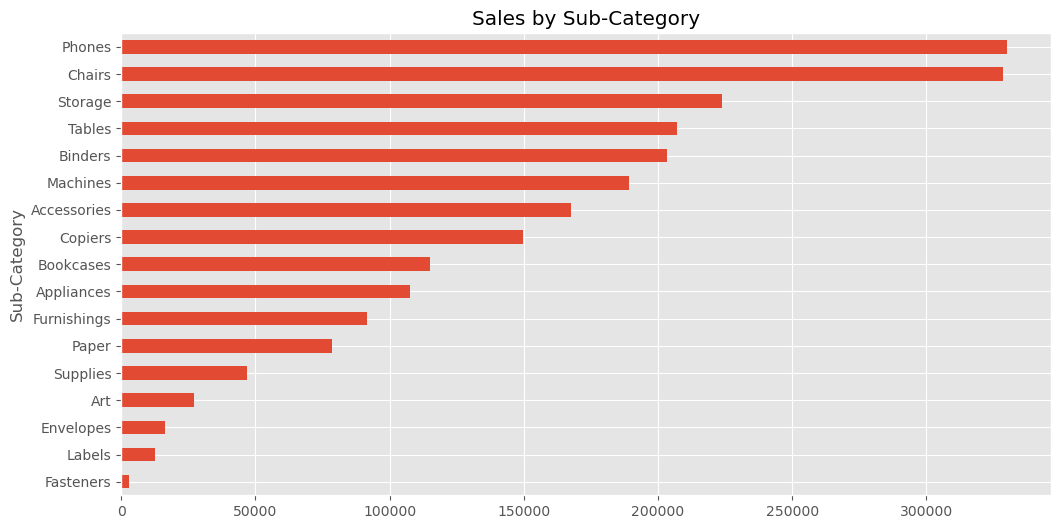

In [17]:
plt.figure(figsize=(12,6))

subcategory = df.groupby("Sub-Category")["Sales"].sum().sort_values()

subcategory.plot(kind="barh")

plt.title("Sales by Sub-Category")

plt.savefig("images/subcategory_sales.png")

plt.show()

## Best Selling Products

The top-selling products are identified based on total sales revenue.

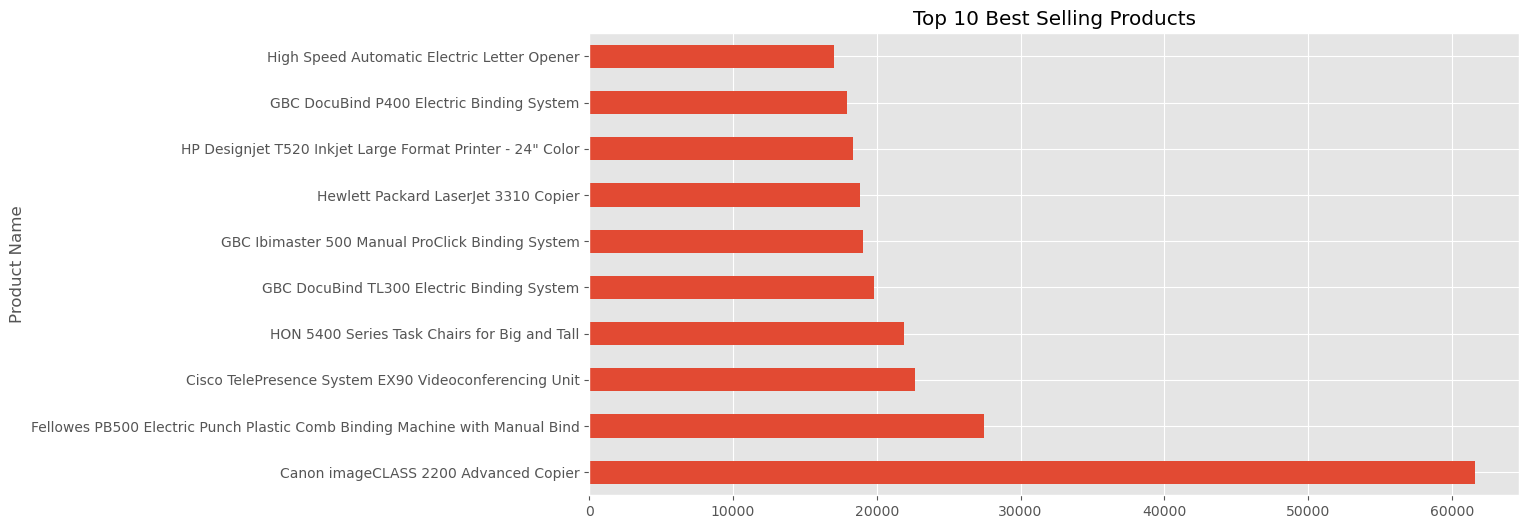

In [18]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

top_products.plot(kind="barh")

plt.title("Top 10 Best Selling Products")

plt.savefig("images/top_products.png")

plt.show()

## Profitability Analysis

Profit analysis helps determine which categories generate the highest profit.

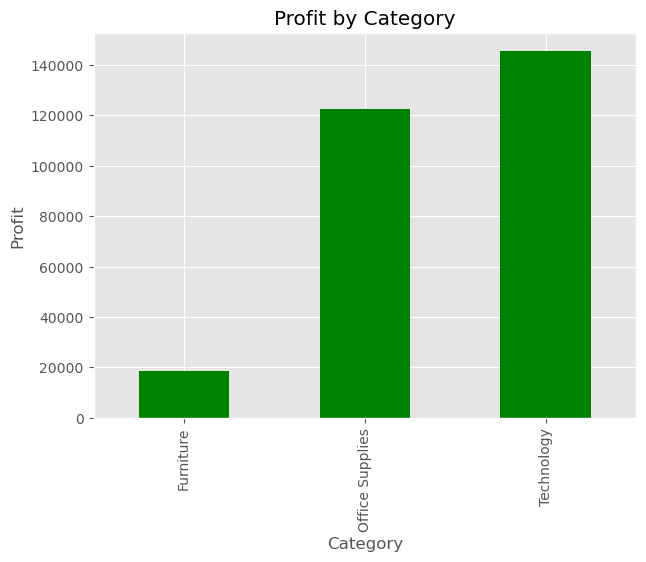

In [19]:
profit = df.groupby("Category")["Profit"].sum()

plt.figure(figsize=(7,5))

profit.plot(kind="bar", color="green")

plt.title("Profit by Category")

plt.ylabel("Profit")

plt.savefig("images/profit_category.png")

plt.show()

## Regional Sales Analysis

Regional performance is analyzed to understand geographical sales distribution.

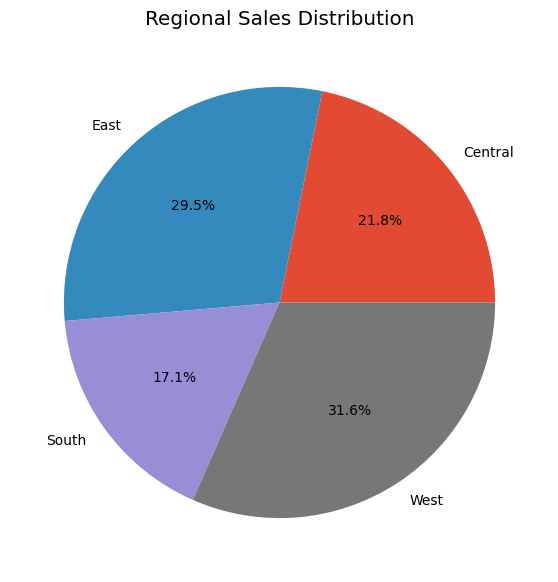

In [20]:
region = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(7,7))

region.plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")

plt.title("Regional Sales Distribution")

plt.savefig("images/region_sales.png")

plt.show()

## Shipping Mode Analysis

This analysis identifies the most frequently used shipping methods.

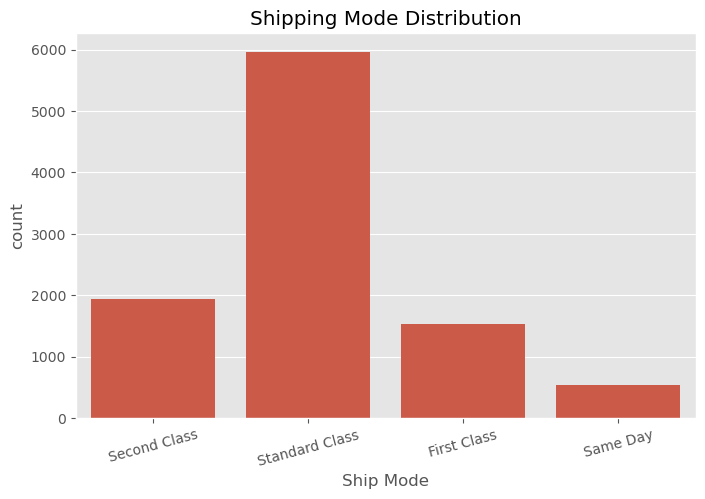

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(x="Ship Mode", data=df)

plt.xticks(rotation=15)

plt.title("Shipping Mode Distribution")

plt.savefig("images/shipping_mode.png")

plt.show()

## Discount vs Profit

This visualization helps understand how discounts affect profitability.

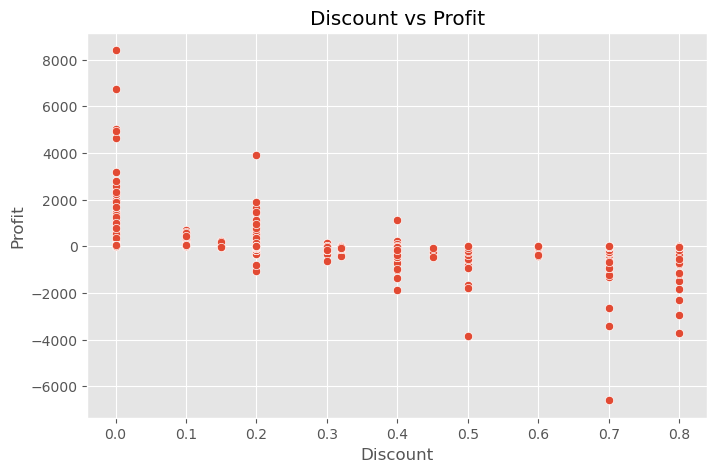

In [22]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Discount",
    y="Profit",
    data=df
)

plt.title("Discount vs Profit")

plt.savefig("images/discount_profit.png")

plt.show()

Higher discounts often lead to lower profits, indicating that excessive discounting negatively impacts business performance.

## Top Customers

Identifying valuable customers helps businesses improve customer relationship management.

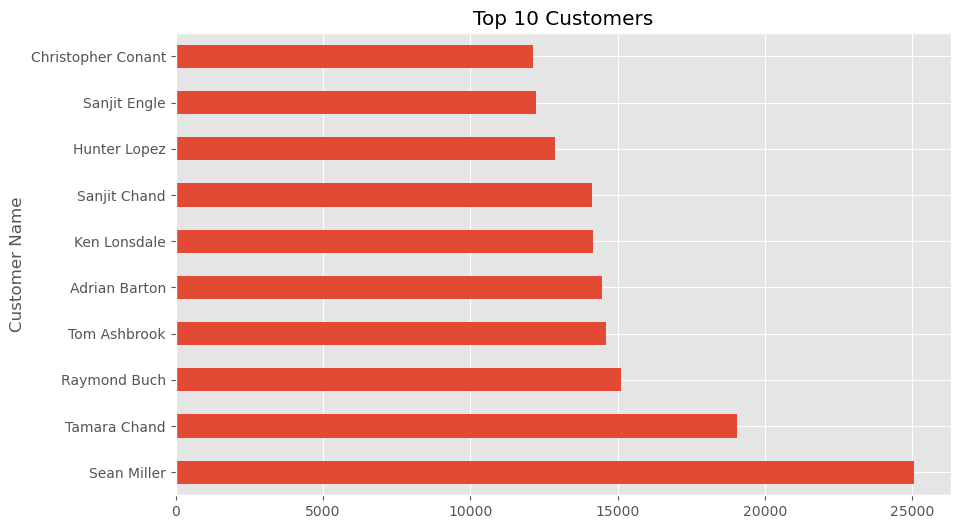

In [23]:
customers = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

customers.plot(kind="barh")

plt.title("Top 10 Customers")

plt.savefig("images/top_customers.png")

plt.show()

## Sales by Customer Segment

Customer segments are compared to determine which segment contributes the most revenue.

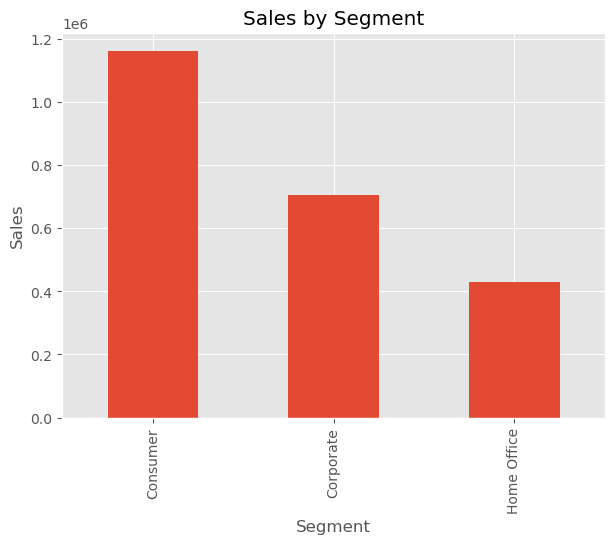

In [24]:
segment = df.groupby("Segment")["Sales"].sum()

plt.figure(figsize=(7,5))

segment.plot(kind="bar")

plt.title("Sales by Segment")

plt.ylabel("Sales")

plt.savefig("images/segment_sales.png")

plt.show()

## Business Insights

* Technology products generated the highest revenue.

* Office Supplies received the highest number of orders.

* A few products contributed significantly to total sales.

* Higher discounts often resulted in lower profits.

* Western region generated strong sales performance.

* Standard Class was the most preferred shipping mode.

* Customer purchasing behavior is concentrated among a few high-value customers.

* Some sub-categories have high sales but relatively low profits.

* Monthly revenue indicates seasonal business trends.

* Profitability can be improved by optimizing discount strategies.

## Conclusion

This project analyzed Superstore sales data to understand business performance through exploratory data analysis and visualization. Monthly revenue trends, sales distribution, profitability, customer behavior, and regional performance were examined. The findings reveal key opportunities for improving sales strategies, managing discounts effectively, and focusing on high-performing products and customers. Overall, this analysis demonstrates how data-driven insights can support better business decision-making.